In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, FactorAnalysis
from factor_analyzer.factor_analyzer import (
    calculate_bartlett_sphericity,
    calculate_kmo
)

np.random.seed(42)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## Data Loading

In [81]:
df = pd.read_csv("data/faang_stock_prices.csv")
print(df.shape)
df.head()

(14964, 19)


,Date,Ticker,Open,High,Low,Close,Volume,SMA_7,SMA_21,EMA_12,EMA_26,RSI_14,MACD,MACD_Signal,Bollinger_Upper,Bollinger_Lower,Daily_Return,Volatility_7d,Next_Day_Close
0,2016-02-23,AAPL,21.853144,21.875812,21.433763,21.465500,127770400,21.782546,21.682435,21.720115,21.827292,52.112369,-0.107176,-0.149939,22.401531,20.889519,-0.022605,0.018130,21.785145
1,2016-02-23,AMZN,27.777500,27.845501,27.266500,27.646999,81016000,26.675857,27.140333,26.765295,27.363824,50.230010,-0.598529,-0.896261,31.103668,22.908382,-0.011725,0.022486,27.702000
2,2016-02-23,GOOGL,36.032746,36.270944,35.515157,35.595547,41332000,35.747473,36.132564,35.810892,36.019909,28.846871,-0.209017,-0.219158,38.439218,33.798573,-0.016131,0.015153,35.774696
3,2016-02-23,META,106.108789,106.724491,104.390794,104.728432,25319300,103.488525,103.976073,103.607174,102.390311,34.031434,1.216863,1.318966,115.829165,92.886882,-0.015864,0.019720,106.138588
4,2016-02-23,MSFT,46.158514,46.184970,44.959133,45.135513,28895300,45.542440,45.303900,45.301104,45.262960,42.877882,0.038144,-0.096534,48.143898,42.459504,-0.027920,0.019161,45.294239


## 2. Missing Values

In [84]:
df.isnull().sum()
print(df.isnull().sum())
df = df.dropna().reset_index(drop=True)

Date               0
Ticker             0
Open               0
High               0
Low                0
Close              0
Volume             0
SMA_7              0
SMA_21             0
EMA_12             0
EMA_26             0
RSI_14             0
MACD               0
MACD_Signal        0
Bollinger_Upper    0
Bollinger_Lower    0
Daily_Return       0
Volatility_7d      0
Next_Day_Close     0
dtype: int64


## 3. Feature Selection
Next_Day_Close is excluded as it is a future target variable. Including it would introduce
information leakage for the model

Date and Ticker are non-numeric identifiers and are also excluded.

In [86]:
df_numeric = df.drop(columns=["Date", "Ticker", "Next_Day_Close"])

## 4. EDA

               Open          High           Low         Close        Volume  \
count  14964.000000  14964.000000  14964.000000  14964.000000  1.496400e+04   
mean     147.969959    149.643762    146.256716    147.999839  1.186247e+08   
std      132.599874    134.001750    131.065146    132.547711  1.889461e+08   
min        0.762756      0.777392      0.746413      0.767738  4.726100e+06   
25%       50.094322     50.468777     49.669161     50.083026  2.428050e+07   
50%      123.841343    125.102966    122.262753    123.922924  4.432600e+07   
75%      189.299623    191.429458    186.986899    189.079613  1.057329e+08   
max      789.972167    795.064526    779.657506    788.823792  3.692928e+09   

              SMA_7        SMA_21        EMA_12        EMA_26        RSI_14  \
count  14964.000000  14964.000000  14964.000000  14964.000000  14964.000000   
mean     147.631588    146.746646    147.314335    146.428158     55.686976   
std      132.261571    131.557653    131.956650    

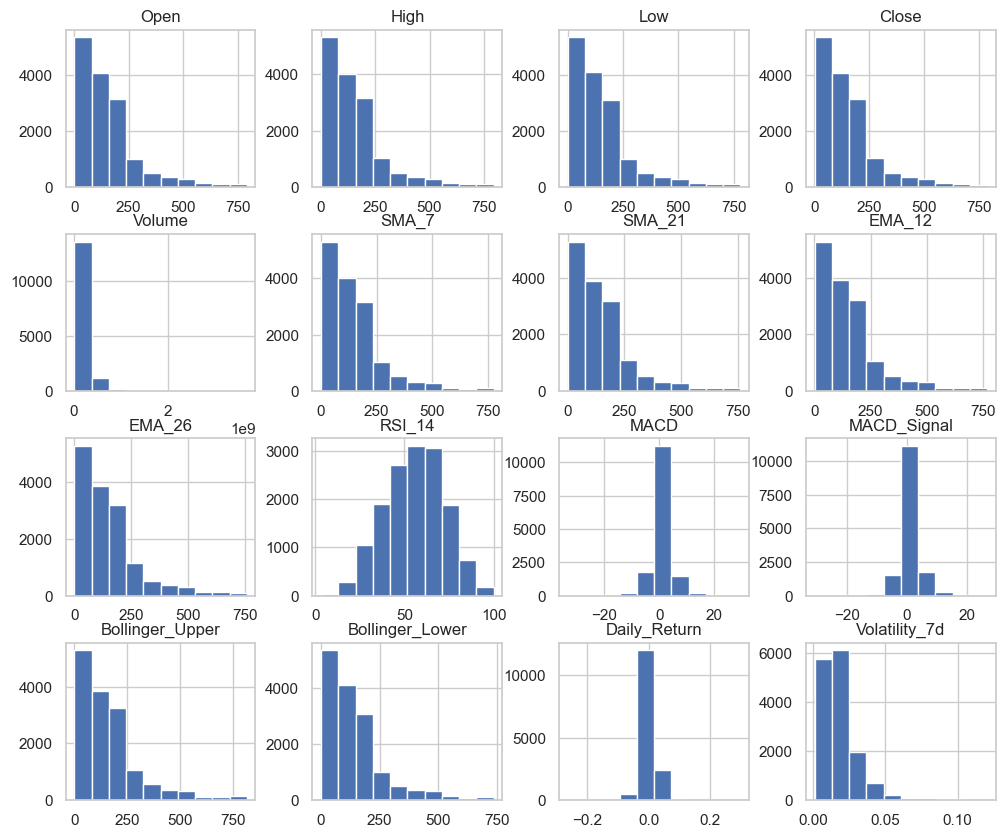

In [87]:
print(df_numeric.describe())

df_numeric.hist(figsize=(12,10))
plt.show()

## 5. Outlier Detection (Z-Score)

In [88]:
from scipy import stats
import pandas as pd

z_scores = pd.DataFrame(
    np.abs(stats.zscore(df_numeric, nan_policy='omit')),
    columns=df_numeric.columns,
    index=df_numeric.index
)
outlier_mask = (z_scores > 3).any(axis=1)
print(f'Rows with at least one feature |Z| > 3: {outlier_mask.sum()} '
      f'({outlier_mask.sum()/len(df_numeric)*100:.2f}% of data)')
print('\nOutlier counts per feature (|Z| > 3):')
print((z_scores > 3).sum().sort_values(ascending=False))



Rows with at least one feature |Z| > 3: 1115 (7.45% of data)

Outlier counts per feature (|Z| > 3):
Bollinger_Upper    331
EMA_26             328
Volume             327
High               324
Open               322
Close              322
EMA_12             321
Low                319
SMA_7              317
SMA_21             317
Bollinger_Lower    293
MACD               281
MACD_Signal        269
Volatility_7d      250
Daily_Return       238
RSI_14               2
dtype: int64


In [89]:
print(f"Rows with outliers: {outlier_mask.sum()}")

Rows with outliers: 1115


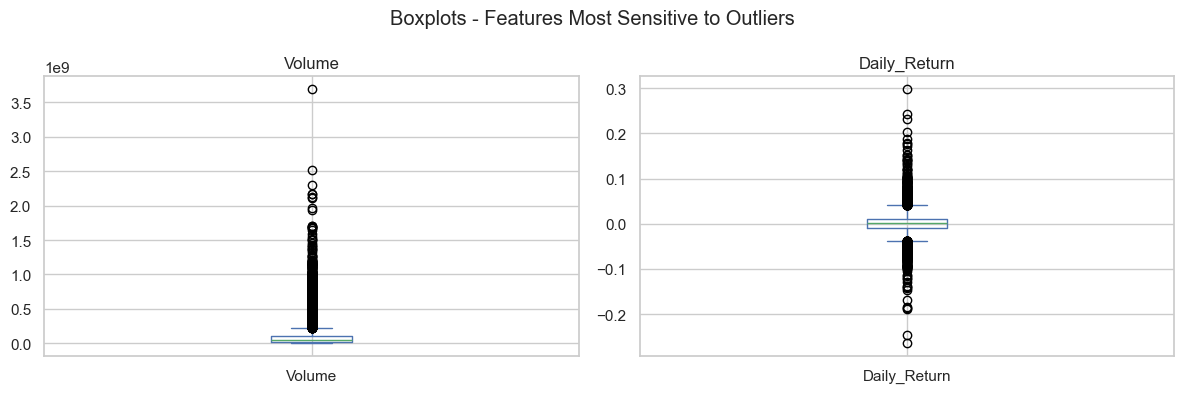

In [125]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_numeric['Volume'].plot(kind='box', ax=axes[0], title='Volume')
df_numeric['Daily_Return'].plot(kind='box', ax=axes[1], title='Daily_Return')
plt.suptitle('Boxplots - Features Most Sensitive to Outliers')
plt.tight_layout()
plt.show()

# Outliers are retained because removing them risks losing genuine market events


## 6. Correlation Matrix

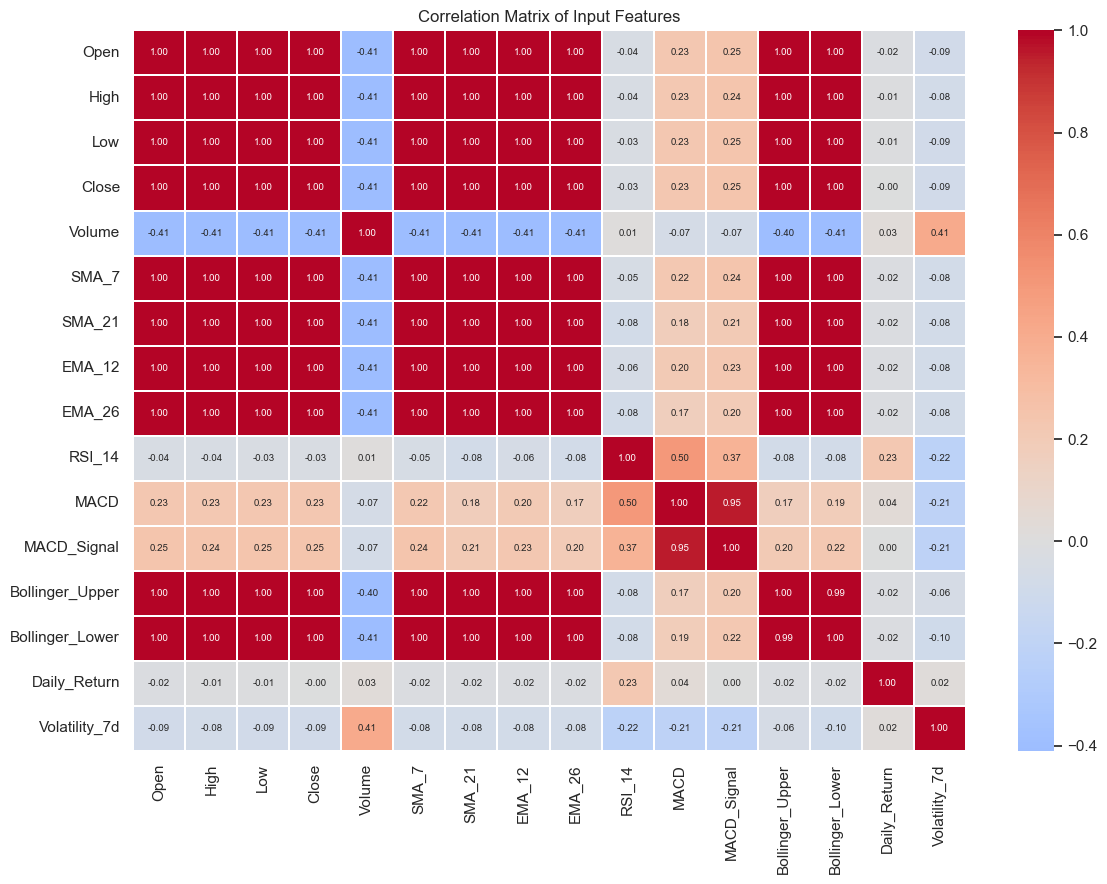

In [42]:
plt.figure(figsize=(12, 9))
sns.heatmap(df_numeric.corr(), cmap='coolwarm', center=0,
            linewidths=0.3, annot=True, fmt='.2f', annot_kws={'size': 7})
plt.title('Correlation Matrix of Input Features')
plt.tight_layout()
plt.show()


## 7. PCA Suitability — Bartlett's Test & KMO

In [94]:
corr_matrix = df_numeric.corr()
det = np.linalg.det(corr_matrix)
print(f'Correlation matrix determinant: {det:.6e}')

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = upper.stack()[upper.stack().abs() > 0.95]
print('\nHighly correlated pairs (|r| > 0.95):')
print(high_corr)

cols_to_drop = list(set([col for col, _ in high_corr.index]))
df_numeric_clean = df_numeric.drop(columns=cols_to_drop)
print(f'\nDropped: {cols_to_drop}')
print(f'Remaining features: {df_numeric_clean.shape[1]}')

chi2, p = calculate_bartlett_sphericity(df_numeric_clean)
print(f"\nBartlett's Test of Sphericity:")
print(f'  chi2 = {chi2:.2f},  p-value = {p:.4e}')
print('  → PCA is appropriate.' if p < 0.05 else '  → WARNING: p >= 0.05.')

kmo_all, kmo_model = calculate_kmo(df_numeric_clean)
print(f'\nKMO Measure of Sampling Adequacy: {kmo_model:.4f}')
if kmo_model >= 0.8:
    print('  → Meritorious: data are well suited for PCA.')
elif kmo_model >= 0.6:
    print('  → Acceptable: PCA is appropriate.')
else:
    print('  → WARNING: KMO < 0.6, PCA may not be well suited.')


Correlation matrix determinant: -1.770559e-48

Highly correlated pairs (|r| > 0.95):
Open             High               0.999871
                 Low                0.999872
                 Close              0.999738
                 SMA_7              0.999372
                 SMA_21             0.997618
                 EMA_12             0.999120
                 EMA_26             0.997816
                 Bollinger_Upper    0.996435
                 Bollinger_Lower    0.996347
High             Low                0.999828
                 Close              0.999874
                 SMA_7              0.999362
                 SMA_21             0.997673
                 EMA_12             0.999141
                 EMA_26             0.997895
                 Bollinger_Upper    0.996647
                 Bollinger_Lower    0.996214
Low              Close              0.999882
                 SMA_7              0.999260
                 SMA_21             0.997364
               

## 8. Standardisation

In [95]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)

print("Mean of scaled data (should be ~0):", np.round(X_scaled.mean(axis=0), 4))
print("Std of scaled data (should be ~1):", np.round(X_scaled.std(axis=0), 4))


Mean of scaled data (should be ~0): [ 0. -0.  0.  0. -0. -0. -0.  0.  0.  0.  0. -0.  0.  0.  0. -0.]
Std of scaled data (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 9. PCA  

In [102]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [103]:
explained = pca.explained_variance_ratio_
eigenvalues = pca.explained_variance_

for i, v in enumerate(explained):
    print(f"PC{i+1}: {v:.4f} ({v*100:.2f}%)")

PC1: 0.6434 (64.34%)
PC2: 0.1429 (14.29%)
PC3: 0.0778 (7.78%)
PC4: 0.0667 (6.67%)
PC5: 0.0367 (3.67%)
PC6: 0.0300 (3.00%)
PC7: 0.0023 (0.23%)
PC8: 0.0003 (0.03%)
PC9: 0.0000 (0.00%)
PC10: 0.0000 (0.00%)
PC11: 0.0000 (0.00%)
PC12: 0.0000 (0.00%)
PC13: 0.0000 (0.00%)
PC14: 0.0000 (0.00%)
PC15: 0.0000 (0.00%)
PC16: 0.0000 (0.00%)


## 10. Scree Plot & Cumulative Variance

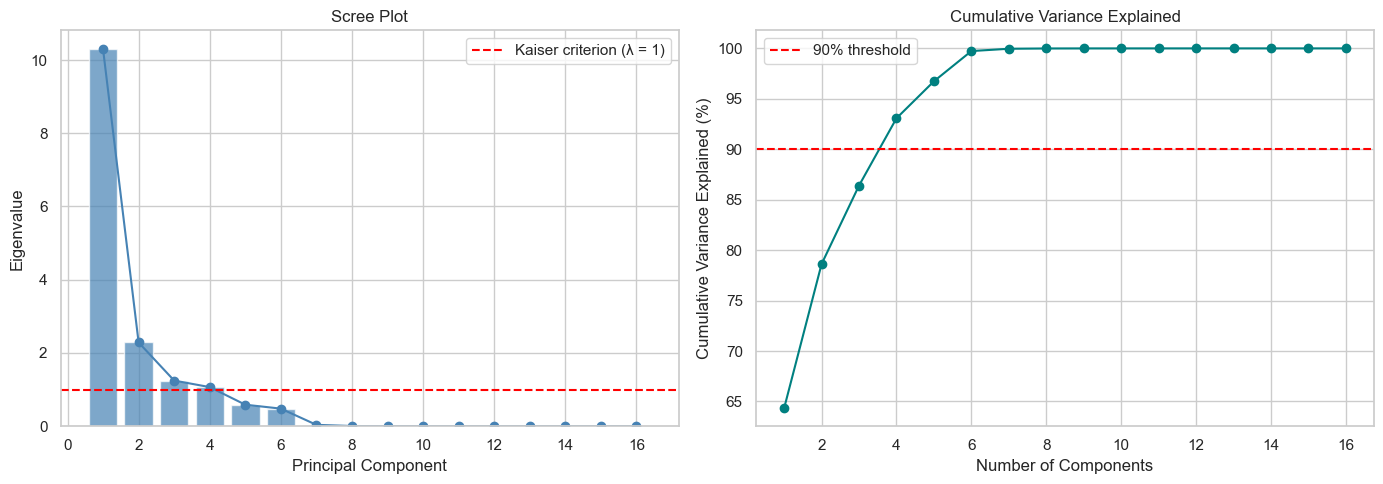

In [104]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.bar(range(1, len(eigenvalues)+1), eigenvalues,
        color='steelblue', alpha=0.7)
ax1.plot(range(1, len(eigenvalues)+1), eigenvalues,
         marker='o', color='steelblue', linewidth=1.5)
ax1.axhline(y=1, linestyle='--', color='red', linewidth=1.5,
            label='Kaiser criterion (λ = 1)')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Eigenvalue')
ax1.set_title('Scree Plot')
ax1.legend()


ax2 = axes[1]
ax2.plot(range(1, len(explained)+1),
         np.cumsum(explained) * 100,
         marker='o', color='teal', linewidth=1.5)
ax2.axhline(90, linestyle='--', color='red', linewidth=1.5,
            label='90% threshold')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Variance Explained (%)')
ax2.set_title('Cumulative Variance Explained')
ax2.legend()

plt.tight_layout()
plt.show()


## 11. Component Selection

In [105]:
kaiser_count     = int(np.sum(eigenvalues > 1))
cumvar_arr       = np.cumsum(explained)
threshold_count  = int(np.argmax(cumvar_arr >= 0.90) + 1)

print(f'Kaiser criterion (eigenvalue > 1): {kaiser_count} components')
print(f'90% variance threshold:            {threshold_count} components')
print('\n-> Both criteria agree: retain 4 components.')

Kaiser criterion (eigenvalue > 1): 4 components
90% variance threshold:            4 components

-> Both criteria agree: retain 4 components.


## 12. Final PCA - 4 Components

In [108]:
pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_scaled)

print(f'Components selected: {pca.n_components_}')

summary = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "Variance Explained": pca.explained_variance_ratio_,
    "Cumulative Variance": np.cumsum(pca.explained_variance_ratio_)
})

print(summary.to_string(index=False))


Components selected: 4
 PC  Variance Explained  Cumulative Variance
PC1            0.643367             0.643367
PC2            0.142862             0.786229
PC3            0.077818             0.864047
PC4            0.066707             0.930754


## 13. Loadings

In [109]:
loadings = pd.DataFrame(
    pca.components_,
    columns=df_numeric.columns,
    index=[f'PC{i+1}' for i in range(pca.n_components_)]
)
print(loadings.round(3))

print('\nTop 5 features per component:')
for i in range(pca.n_components_):
    print(f'\nPC{i+1}:')
    print(loadings.iloc[i].abs().sort_values(ascending=False).head(5))

      Open   High    Low  Close  Volume  SMA_7  SMA_21  EMA_12  EMA_26  \
PC1  0.311  0.311  0.311  0.311  -0.139  0.311   0.310   0.311   0.310   
PC2 -0.018 -0.020 -0.016 -0.017  -0.033 -0.026  -0.052  -0.035  -0.054   
PC3  0.033  0.036  0.032  0.035   0.640  0.031   0.025   0.029   0.024   
PC4  0.008  0.013  0.014  0.019  -0.097  0.003   0.008   0.006   0.012   

     RSI_14   MACD  MACD_Signal  Bollinger_Upper  Bollinger_Lower  \
PC1  -0.011  0.079        0.086            0.310            0.310   
PC2   0.474  0.601        0.567           -0.056           -0.043   
PC3   0.036  0.154        0.152            0.036            0.014   
PC4   0.320 -0.186       -0.256            0.009            0.005   

     Daily_Return  Volatility_7d  
PC1        -0.006         -0.037  
PC2         0.101         -0.259  
PC3         0.179          0.708  
PC4         0.885         -0.062  

Top 5 features per component:

PC1:
Low      0.311143
Open     0.311119
SMA_7    0.311117
Close    0.311088

## 14. Loading Plots

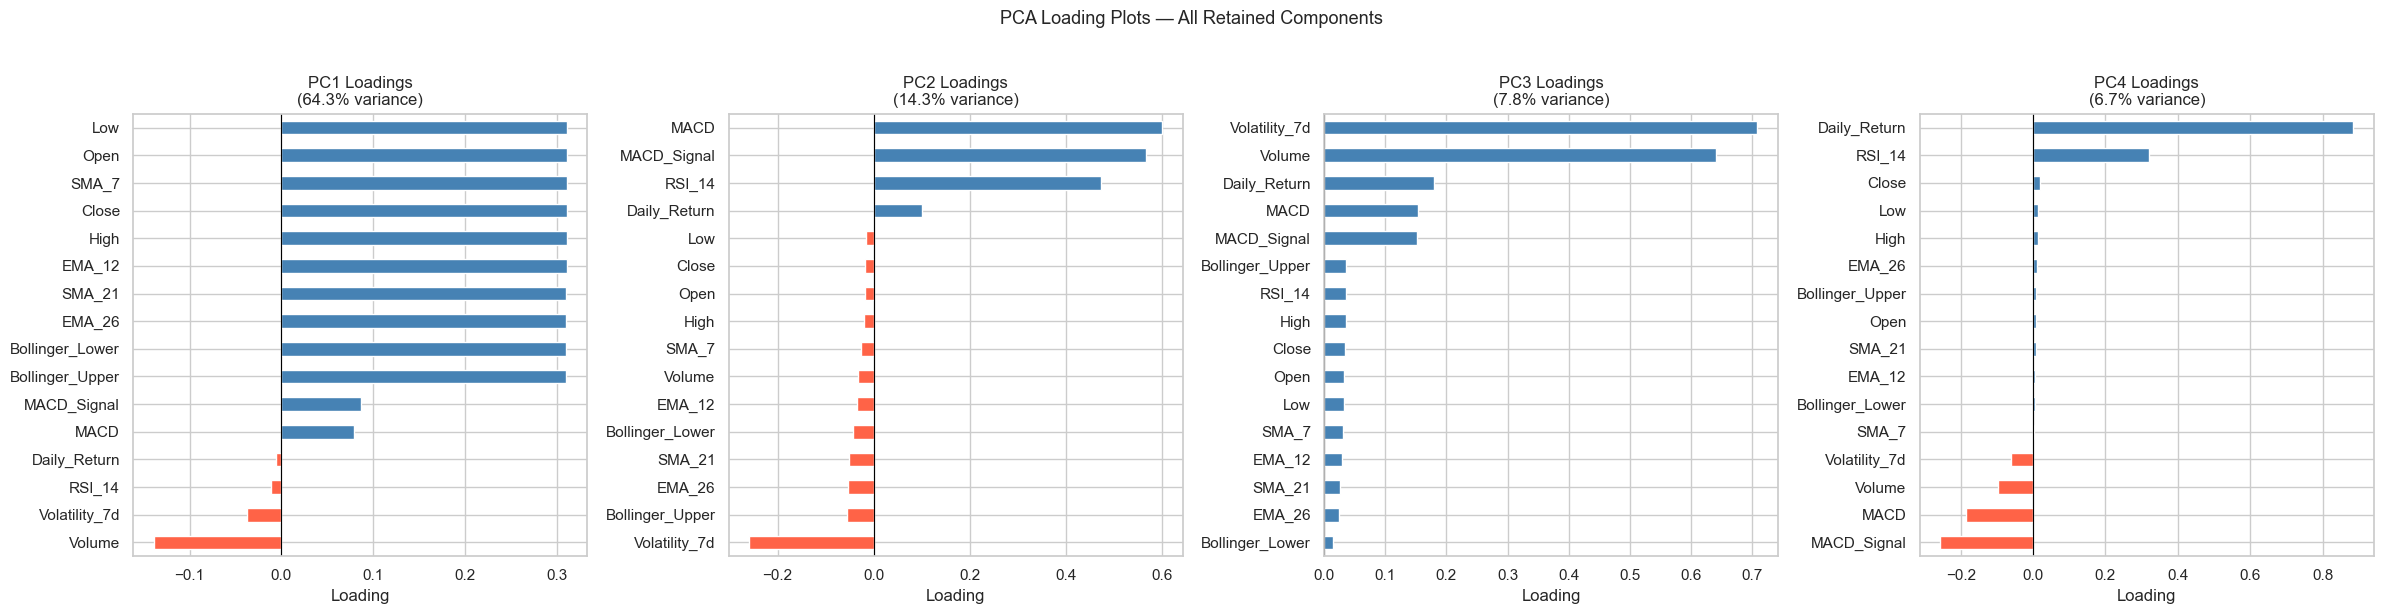

In [110]:
n_pcs = pca.n_components_
fig, axes = plt.subplots(1, n_pcs, figsize=(6 * n_pcs, 6))
if n_pcs == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    pc_label = f'PC{i+1}'
    vals     = loadings.loc[pc_label].sort_values()
    colours  = ['tomato' if v < 0 else 'steelblue' for v in vals]
    vals.plot(kind='barh', ax=ax, color=colours)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(
        f'{pc_label} Loadings\n'
        f'({pca.explained_variance_ratio_[i]*100:.1f}% variance)'
    )
    ax.set_xlabel('Loading')

plt.suptitle('PCA Loading Plots — All Retained Components', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 15. Score Plots

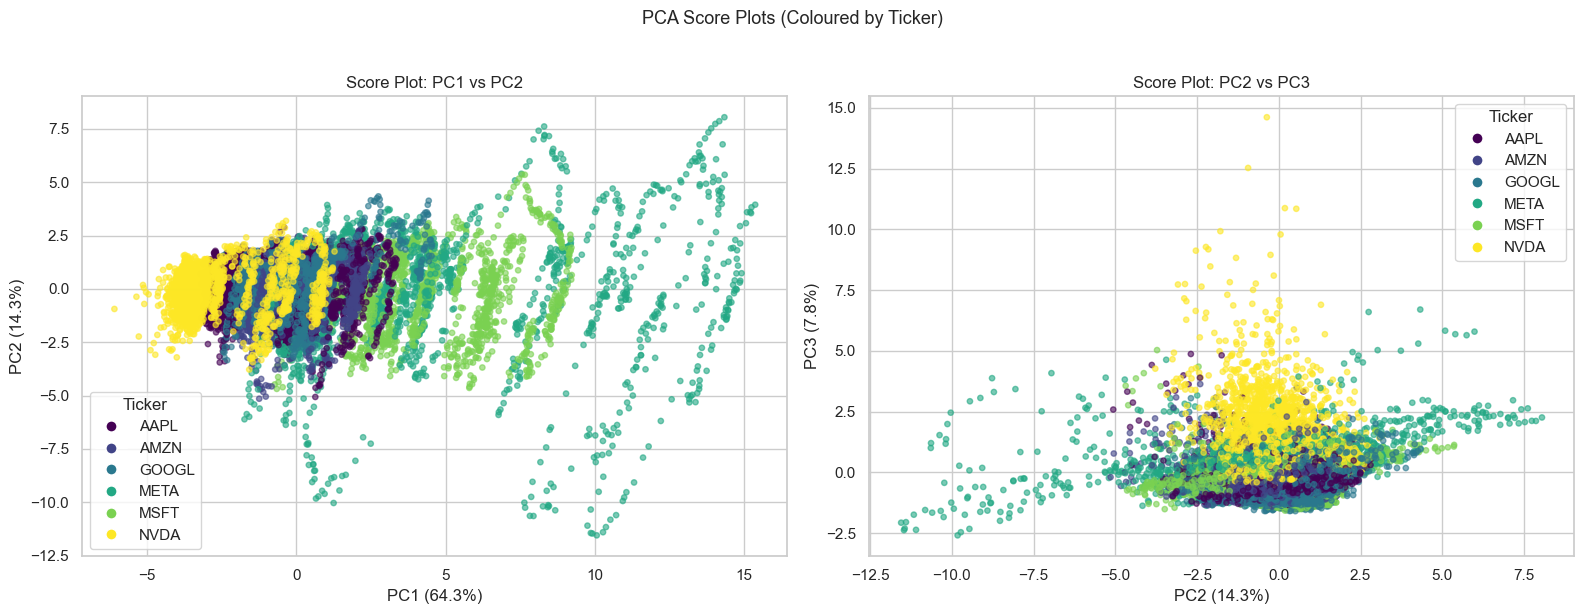

In [111]:
tickers      = df['Ticker'].astype('category')
ticker_codes = tickers.cat.codes
ticker_labels= tickers.cat.categories
unique_codes = sorted(ticker_codes.unique())

def make_legend(unique_codes, ticker_labels):
    return [
        plt.Line2D([0], [0], marker='o', color='w',
                   markerfacecolor=plt.cm.viridis(c / max(unique_codes)),
                   markersize=8, label=ticker_labels[c])
        for c in unique_codes
    ]

pairs = [(0,1), (1,2)]
fig, axes = plt.subplots(1, len(pairs), figsize=(8*len(pairs), 6))

for ax, (xi, yi) in zip(axes, pairs):
    ax.scatter(X_pca[:,xi], X_pca[:,yi], c=ticker_codes, cmap='viridis', alpha=0.6, s=15)
    ax.legend(handles=make_legend(unique_codes, ticker_labels), title='Ticker', loc='best')
    vx = pca.explained_variance_ratio_[xi]*100
    vy = pca.explained_variance_ratio_[yi]*100
    ax.set_xlabel(f'PC{xi+1} ({vx:.1f}%)')
    ax.set_ylabel(f'PC{yi+1} ({vy:.1f}%)')
    ax.set_title(f'Score Plot: PC{xi+1} vs PC{yi+1}')

plt.suptitle('PCA Score Plots (Coloured by Ticker)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 16. Biplots

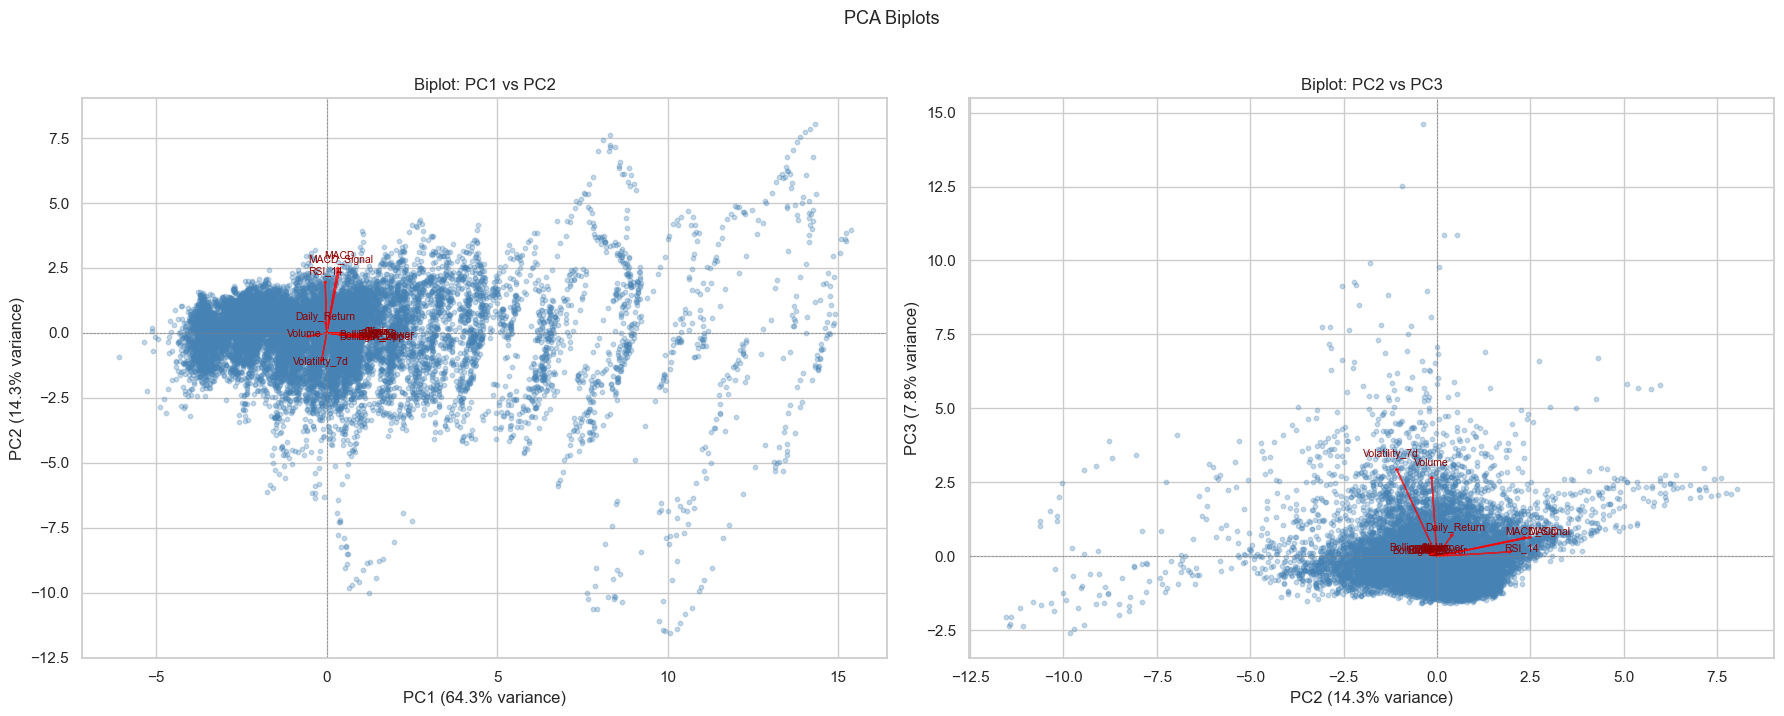

In [71]:
pairs = [(0, 1), (1, 2)] if pca.n_components_ >= 3 else [(0, 1)]
fig, axes = plt.subplots(1, len(pairs), figsize=(9 * len(pairs), 7))
if len(pairs) == 1:
    axes = [axes]

# Scale arrows relative to score spread
score_scale = np.abs(X_pca[:, :2]).mean() * 2.5

for ax, (xi, yi) in zip(axes, pairs):
    ax.scatter(X_pca[:, xi], X_pca[:, yi],
               alpha=0.3, s=10, color='steelblue')
    ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')

    for feature in df_numeric.columns:
        x = loadings.loc[f'PC{xi+1}', feature] * score_scale
        y = loadings.loc[f'PC{yi+1}', feature] * score_scale
        ax.arrow(0, 0, x, y, color='red', alpha=0.75,
                 head_width=score_scale * 0.02,
                 head_length=score_scale * 0.015,
                 length_includes_head=True)
        ax.text(x * 1.13, y * 1.13, feature,
                fontsize=7.5, color='darkred', ha='center')

    vx = pca.explained_variance_ratio_[xi] * 100
    vy = pca.explained_variance_ratio_[yi] * 100
    ax.set_xlabel(f'PC{xi+1} ({vx:.1f}% variance)')
    ax.set_ylabel(f'PC{yi+1} ({vy:.1f}% variance)')
    ax.set_title(f'Biplot: PC{xi+1} vs PC{yi+1}')

plt.suptitle('PCA Biplots', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 17. Reconstruction Error

In [113]:
X_reconstructed = pca.inverse_transform(X_pca)

error = np.mean((X_scaled - X_reconstructed) ** 2)
print(f"Reconstruction Error (MSE): {error:.6f}")
print(f"Variance retained: {pca.explained_variance_ratio_.sum()*100:.2f}%")
print(f"Variance lost:     {(1 - pca.explained_variance_ratio_.sum())*100:.2f}%")


Reconstruction Error (MSE): 0.069246
Variance retained: 93.08%
Variance lost:     6.92%


## 18. Component Interpretation
PC1 - Market Price Level Factor (64.3%): Dominated by all price-based indicators (Open, Close, High, Low, SMA, EMA, Bollinger Bands). Captures the overall price level and long-term upward trend common across FAANG stocks.

PC2 - Momentum / Oscillator Factor (14.3%): Driven by MACD, MACD_Signal, and RSI_14. Distinguishes overbought conditions from oversold regimes, reflecting short-term directional momentum.

PC3 - Volume / Volatility Factor (7.8%): Primarily influenced by Volume and Volatility_7d. Separates high-activity, volatile trading sessions from calm ones.

PC4 - Residual / Daily Return Factor (6.7%): Captures Daily_Return variation not explained by the other components.



## 19. Comparison with Factor Analysis

In [114]:
fa = FactorAnalysis(n_components=pca.n_components_)
X_fa = fa.fit_transform(X_scaled)

fa_loadings = pd.DataFrame(
    fa.components_,
    columns=df_numeric.columns,
    index=[f"FA{i+1}" for i in range(pca.n_components_)]
)

print("Factor Analysis Loadings:")
print(fa_loadings.head().round(3))

Factor Analysis Loadings:
      Open   High    Low  Close  Volume  SMA_7  SMA_21  EMA_12  EMA_26  \
FA1  0.999  0.999  0.998  0.998  -0.407  1.000   1.000   1.000   1.000   
FA2 -0.041 -0.039 -0.044 -0.042  -0.009 -0.030   0.012  -0.015   0.016   
FA3  0.009  0.012  0.007  0.010   0.056  0.003  -0.008   0.000   0.000   
FA4 -0.028 -0.029 -0.033 -0.032   0.051 -0.000   0.008   0.000   0.000   

     RSI_14   MACD  MACD_Signal  Bollinger_Upper  Bollinger_Lower  \
FA1  -0.068  0.189        0.216            0.999            0.998   
FA2  -0.522 -0.982       -0.930            0.017            0.002   
FA3   0.191 -0.000       -0.127            0.038           -0.059   
FA4  -0.285  0.000        0.218            0.019           -0.003   

     Daily_Return  Volatility_7d  
FA1        -0.021         -0.079  
FA2        -0.042          0.200  
FA3         0.037          0.325  
FA4        -0.292          0.113  


In [118]:
comparison = pd.DataFrame({
    "PCA PC1": loadings.loc["PC1"].round(3),
    "FA Factor 1": fa_loadings.loc["FA1"].round(3)
})
comparison['Abs Difference'] = (comparison['PCA PC1'] - comparison['FA Factor 1']).abs().round(3)
print("PC1 vs FA Factor 1 - Loading Comparison:")
print(comparison)


PC1 vs FA Factor 1 - Loading Comparison:
                 PCA PC1  FA Factor 1  Abs Difference
Open               0.311        0.999           0.688
High               0.311        0.999           0.688
Low                0.311        0.998           0.687
Close              0.311        0.998           0.687
Volume            -0.139       -0.407           0.268
SMA_7              0.311        1.000           0.689
SMA_21             0.310        1.000           0.690
EMA_12             0.311        1.000           0.689
EMA_26             0.310        1.000           0.690
RSI_14            -0.011       -0.068           0.057
MACD               0.079        0.189           0.110
MACD_Signal        0.086        0.216           0.130
Bollinger_Upper    0.310        0.999           0.689
Bollinger_Lower    0.310        0.998           0.688
Daily_Return      -0.006       -0.021           0.015
Volatility_7d     -0.037       -0.079           0.042


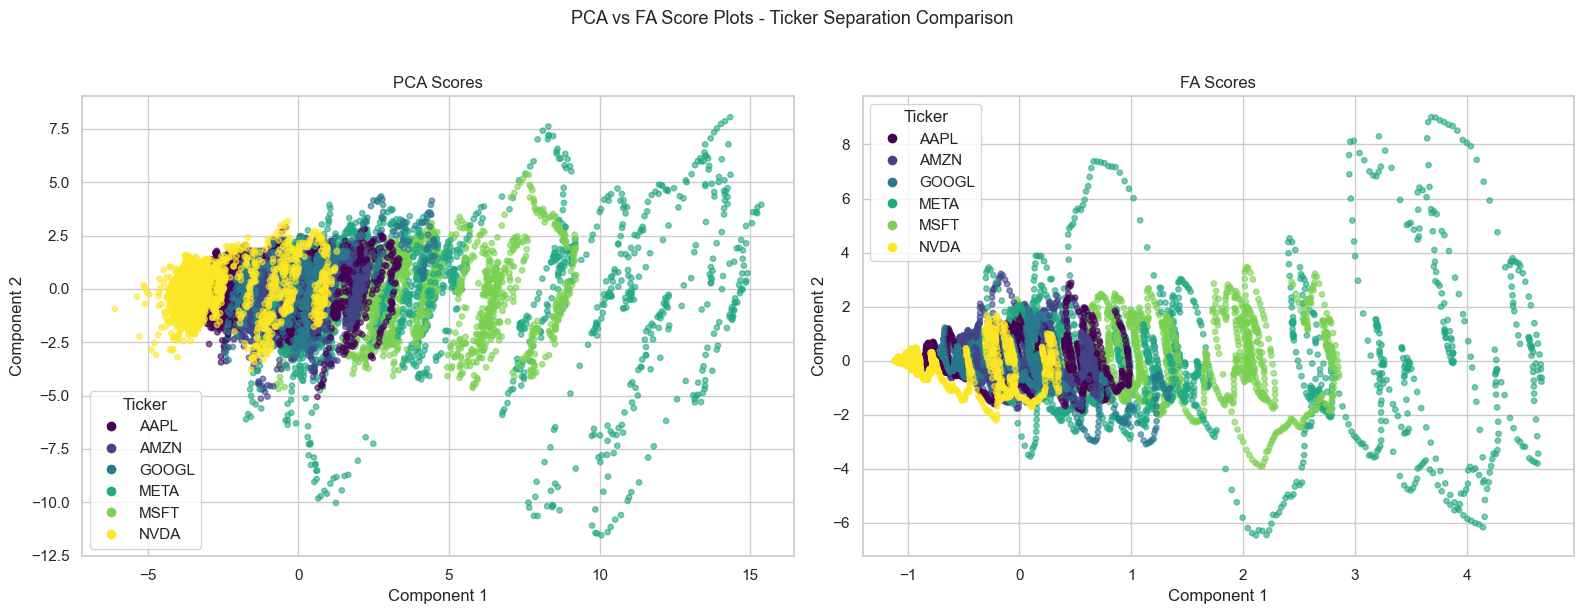

In [119]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (scores, label) in zip(axes, [(X_pca,'PCA Scores'), (X_fa,'FA Scores')]):
    ax.scatter(scores[:,0], scores[:,1], c=ticker_codes, cmap='viridis', alpha=0.6, s=15)
    ax.legend(handles=make_legend(unique_codes, ticker_labels), title='Ticker', loc='best')
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    ax.set_title(label)

plt.suptitle('PCA vs FA Score Plots - Ticker Separation Comparison', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 20. Sensitivity Analysis

In [120]:
print('Sensitivity to variance threshold:')
print(f"{'Threshold':>10} | {'Components':>10} | {'Variance Retained':>18}")
print('-' * 44)
sensitivity_models = {}
for t in [0.80, 0.90, 0.95]:
    m = PCA(n_components=t).fit(X_scaled)
    sensitivity_models[t] = m
    print(f"{int(t*100):>9}% | {m.n_components_:>10} | "
          f"{m.explained_variance_ratio_.sum()*100:>17.2f}%")

Sensitivity to variance threshold:
 Threshold | Components |  Variance Retained
--------------------------------------------
       80% |          3 |             86.40%
       90% |          4 |             93.08%
       95% |          5 |             96.74%


In [123]:
pca_80 = sensitivity_models[0.80]
pca_90 = sensitivity_models[0.90]

stability = pd.DataFrame({
    'PC1 @ 80%': pca_80.components_[0].round(4),
    'PC1 @ 90%': pca_90.components_[0].round(4),
}, index=df_numeric.columns)
stability['Abs Diff'] = (stability['PC1 @ 80%'] - stability['PC1 @ 90%']).abs().round(4)
print('PC1 loading stability:')
print(stability)
print(f'\nMax absolute difference: {stability["Abs Diff"].max():.4f}')
if stability['Abs Diff'].max() < 0.05:
    print('PC1 loadings are stable')
else:
    print('Some loading are instable .')


PC1 loading stability:
                 PC1 @ 80%  PC1 @ 90%  Abs Diff
Open                0.3111     0.3111       0.0
High                0.3111     0.3111       0.0
Low                 0.3111     0.3111       0.0
Close               0.3111     0.3111       0.0
Volume             -0.1390    -0.1390       0.0
SMA_7               0.3111     0.3111       0.0
SMA_21              0.3104     0.3104       0.0
EMA_12              0.3110     0.3110       0.0
EMA_26              0.3103     0.3103       0.0
RSI_14             -0.0109    -0.0109       0.0
MACD                0.0786     0.0786       0.0
MACD_Signal         0.0862     0.0862       0.0
Bollinger_Upper     0.3098     0.3098       0.0
Bollinger_Lower     0.3103     0.3103       0.0
Daily_Return       -0.0061    -0.0061       0.0
Volatility_7d      -0.0371    -0.0371       0.0

Max absolute difference: 0.0000
PC1 loadings are stable


## 21. Limitations

1. **Linearity**: PCA assumes linear relationships. Stock dynamics may have non-linear dependencies (volatility clustering, regime shifts) that Kernel PCA or t-SNE would better capture.
2. **Non-stationarity**: Price-based features (Open, Close, EMA, SMA) are non-stationary. PC1 reflects price magnitude rather than market dynamics. Using returns instead of price levels would mitigate this.
3. **Temporal structure ignored**: PCA treats rows as i.i.d. observations, ignoring autocorrelation inherent in time-series data.
4. **Post-hoc interpretation**: Component labels (price, momentum, volatility) are assigned after the fact and may not generalise to other datasets or time periods.
5. **Outlier sensitivity**: PCA is sensitive to extreme values. Outliers in Volume and Daily_Return were retained to preserve genuine market events, but their influence on component directions is a limitation.
6. **Multicollinearity**: High correlation between price features means PC1 is essentially a price-level index rather than a more informative composite.